# Lean-21 : Detection MIMO par flips -- le seuil 2 log N sous preuve Lean

**Navigation** : [Index](README.md) | [Lean-20 (PFR)](Lean-20-PFR-Entropy-Method.ipynb) | [Lean-22 (Galois) >>](Lean-22-Galois-Probleme-Inverse-M23.ipynb)

Ce notebook presente le lake **`mimo_lean`** de ce depot (issue #10984) : le port
formel de l'algorithme de detection MIMO par flips de coordonnées de
**Papailiopoulos (2026)**. Le resultat central du papier est un **seuil de
faisabilite** : la detection ML (maximum de vraisemblance) reussit au-dessus
d'un seuil en ~`2·log N` et echoue en dessous.

Le lake formalise ce resultat en **quatre phases**, toutes completees et
sorry-free :

| Phase | Module | Resultat |
|-------|--------|----------|
| 1 | `Descent.lean` | Proposition 9.1 (squelette combinatoire, sans Mathlib) |
| 2 | `Objective.lean` | Lemme 11.1 : forme fermee du cout d'un flip |
| 3a | `Lmmse.lean` | Lemme 5.1 : erreur LMMSE = trace de `B_ρ` |
| 3b | `Converse.lean` | Converse §11 : briques gaussiennes + assemblage (lake externe SLT) |

Depuis, le pont `Bridge.lean` (codes 2.3-2.4) a referme la chaine jusqu'a
l'enonce terminal du Thm 2.1 : sous couverture diagonale et seuil
`M·ε·φ(2) ≥ 2·log N − log log N`, `P(erreur ML) ≥ 1 − exp(−(2·log N − log log N))`
(issues #11673, #11709).

Comme dans [Lean-20](Lean-20-PFR-Entropy-Method.ipynb), nous procedons en deux
registres : des **illustrations numeriques** (Python) qui montrent les phenomenes,
puis des **`#check` reels** executes par `lake env lean` sur le lac compile --
les enonces affiches sont ceux que le compilateur Lean 4 a verifies, pas des
paraphrases.

## Une question laissée en friche pendant vingt-cinq ans

Le résultat formalisé ici clôt une question que la communauté des communications sans fil a intensivement travaillée de 2000 à la fin des années 2010, avant de passer à autre chose. L'auteur raconte cette histoire dans un article de vulgarisation (août 2026) qui mérite d'être lu en entier ; en voici la colonne vertébrale :

| Année | Événement |
|---|---|
| 1989 | Verdú démontre que la détection ML (moindres carrés entiers) est **NP-difficile** dans le cas général. Mais la dureté NP est un énoncé du pire cas -- et un canal gaussien n'est pas un adversaire. |
| 2001 | Hassibi et Vikalo analysent le *Sphere Decoder* (Fincke--Pohst, 1985), algorithme **exact** dont la complexité espérée « ressemble à un polynôme ». L'espoir naît que la détection exacte soit polynomiale en moyenne. |
| 2005 | Jaldén et Ottersten referment la porte : à SNR fixé, aussi grand soit-il, la complexité **espérée** du sphere decoding reste exponentielle en la dimension. |
| 2000--2010 | La communauté se tourne vers les approximations : relaxations semi-définies (garanties à haut SNR, pas de seuil exact), bit-flipping qui « semble » égaler ML en simulation (sans preuve), AMP (erreur par bit là où le bloc est irrécupérable), physique statistique (prédictions par arguments de réplique, sans preuve au seuil), MCMC (garantie sur la loi stationnaire, rien sur le temps de mélange). |
| 2020 | La relaxation en boîte obtient la première garantie polynomiale de récupération du bloc... à SNR ~ 4 log N -- le **double** du seuil ML -- et l'on prouve qu'elle ne peut pas faire mieux. |
| 2026 | Théorème 2.1 : LMMSE signé puis flips gloutons réussit dès **2 log N**, en temps polynomial. L'écart entre ce que ML atteint et ce qu'un algorithme polynomial peut prouver est refermé. |

Pendant ce temps, le champ avait déménagé. L'auteur le dit sans amertume : des pans entiers de la littérature restent « ouverts et seuls », non parce qu'ils sont impossibles, mais parce que les gens ont lentement arrêté de s'en soucier. Ce que ce théorème aurait valu vers 2010 -- un best paper ISIT ou IT Society, des entretiens à MIT, Berkeley, Stanford -- vaut aujourd'hui un préprint et un article sur X : la question n'a pas changé, son audience a disparu.

## 1. Le modele MIMO et le detecteur a flips

Une transmission MIMO a `N` antennes emisuelles et `M` recepteurs se modelise par

$$ y = Hx + w $$

ou `x` est le vecteur de symboles (constellation discrete, ex. BPSK `{±1}`),
`H` la matrice de canal, et `w` un bruit gaussien. La **detection ML** cherche
l'element de la constellation maximisant la vraisemblance -- un probleme
combinatoire a `2^N` candidats en BPSK.

L'algorithme de Papailiopoulos part d'une estimée initiale et applique des
**flips de coordonnees** : retourner une coordonnee `i` de `x` si cela diminue
l'objectif `‖y − Hx‖²`. Chaque flip **accepte** fait strictement decroitre le
cout : la descente ne peut pas revisiter un etat et son nombre de pas est
majore par le cout initial (Phase 1). Le Lemme 11.1 (Phase 2) donne la forme
fermee du cout d'un flip : accepter la coordonnee `i` equivaut a tester le signe
de `s·‖h_i‖² + √s·⟪h_i, w⟫`.

In [1]:
# Code 1.1 - Descente a flips sur un canal MIMO simule
#
# On simule y = Hx + w en BPSK (x_i = ±1), puis on execute le detecteur :
# partir d'une initialisation (filtre apparie), retourner iterativement la
# coordonnee qui diminue le plus ||y - Hx||^2, s'arreter quand aucun flip
# n'est accepte. On mesure : nombre de flips (a comparer au seuil M_N ~ 2 log N)
# et erreur de detection.

import numpy as np

rng = np.random.default_rng(42)

def flip_descent(H, y, x0, max_flips=None):
    """Descente gloutonne a flips : accepter un flip ssi l'objectif decroit strictement.

    Retourne (x_final, nombre_de_flips_acceptes).
    """
    x = x0.copy()
    obj = np.sum((y - H @ x) ** 2)
    flips = 0
    max_flips = max_flips if max_flips is not None else len(x) ** 2
    while flips < max_flips:
        best_gain, best_i = 0.0, None
        for i in range(len(x)):
            x[i] = -x[i]                      # candidat : flip de la coordonnee i
            obj_new = np.sum((y - H @ x) ** 2)
            gain = obj - obj_new              # > 0 si le flip diminue l'objectif
            x[i] = -x[i]                      # restaurer avant de tester la suite
            if gain > best_gain:
                best_gain, best_i = gain, i
        if best_i is None:
            break                              # run terminal : aucun flip accepte
        x[best_i] = -x[best_i]
        obj -= best_gain
        flips += 1
    return x, flips

# Un scenario jouable : N = M = 8, SNR moderee
N = 8
H = rng.standard_normal((N, N))
x_true = rng.choice([-1.0, 1.0], size=N)
w = 0.8 * rng.standard_normal(N)
y = H @ x_true + w

x0 = np.sign(H.T @ y)                         # initialisation filtre apparie
x_hat, n_flips = flip_descent(H, y, x0)
M_N = 2 * np.log(N)                           # echelle du seuil du papier

print(f"N = {N} antennes, seuil indicatif M_N ~ 2 log N = {M_N:.2f}")
print(f"flips acceptes par la descente : {n_flips} (plafond theorique : strictement < M_N sous les hypotheses)")
print(f"erreurs de detection          : {int(np.sum(x_hat != x_true))} / {N} symboles")

N = 8 antennes, seuil indicatif M_N ~ 2 log N = 4.16
flips acceptes par la descente : 3 (plafond theorique : strictement < M_N sous les hypotheses)
erreurs de detection          : 0 / 8 symboles


**Ce que montre la sortie.** La descente s'arrete d'elle-meme (aucun flip
n'ameliore plus l'objectif) : c'est le **run terminal** de la Proposition 9.1.
Le nombre de flips est petit devant `N` -- la Phase 1 prouve qu'il est
strictement majore par `M_N` des que le cout initial est confine sous une
barriere `B < M_N`. Notez aussi que la descente peut echouer (symboles errones) :
c'est exactement la question du seuil -- sous `2·log N` (bruit fort / canal
defavorable), aucune methode ne recupere le message (converse, Phase 3b).

In [2]:
# Code 1.2 - Probabilite d'echappement du bruit (brique du converse)
#
# Le coeur du converse §11 : le recepteur ne peut distinguer le bon symbole x
# d'un voisin x' que si le bruit w ne tombe PAS dans l'union des "intervalles
# d'ambiguite" autour des directions de separation. Pour chaque coordonnee,
# l'evenement "la coordonnee i de w s'echappe de l'intervalle [c-e/2, c+e/2]
# inclus dans [-2, 2]" a une masse m_i >= largeur * phi(2) (Brique 1 du lac).
# Par independance des coordonnees, P(toutes echappees) = prod(1 - m_i), puis
# <= (1-p)^n <= e^{-n p} avec p = eps * phi(2) (Brique 2).
#
# Verification Monte-Carlo de l'identite produit et des bornes.

import numpy as np

rng = np.random.default_rng(7)

phi = lambda t: np.exp(-t ** 2 / 2) / np.sqrt(2 * np.pi)
eps, c = 0.5, 0.0                    # intervalle [c-eps/2, c+eps/2] dans [-2, 2]
n = 12
p = eps * phi(2)                     # borne inferieure de masse par intervalle

# masse exacte de l'intervalle pour la gaussienne centree reduite
from math import erf
mass = 0.5 * (erf((c + eps / 2) / np.sqrt(2)) - erf((c - eps / 2) / np.sqrt(2)))

# Monte-Carlo : une coordonnee "echappee" = hors de l'intervalle
trials = 200_000
w = rng.standard_normal((trials, n))
escaped = np.all(np.abs(w - c) > eps / 2, axis=1)
mc = escaped.mean()

prod_exact = (1 - mass) ** n         # = prod (1 - m_i) quand tous les m_i egaux
bound_pow = (1 - p) ** n             # Brique 2, premiere inegalite
bound_exp = np.exp(-n * p)           # Brique 2, seconde inegalite

print(f"masse d'un intervalle      : m = {mass:.4f} (borne Brique 1 : m >= p = eps*phi(2) = {p:.4f})")
print(f"P(toutes echappees) MC     : {mc:.5f}  ({trials} essais)")
print(f"produit exact (1-m)^n      : {prod_exact:.5f}")
print(f"chaine (1-m)^n <= (1-p)^n  : {prod_exact:.5f} <= {bound_pow:.5f} : {prod_exact <= bound_pow}")
print(f"chaine (1-p)^n <= e^(-n p) : {bound_pow:.5f} <= {bound_exp:.5f} : {bound_pow <= bound_exp}")
print("(les bornes en p = masse MINIMALE sont valides mais laches quand eps est petit)")

masse d'un intervalle      : m = 0.1974 (borne Brique 1 : m >= p = eps*phi(2) = 0.0270)
P(toutes echappees) MC     : 0.07175  (200000 essais)
produit exact (1-m)^n      : 0.07143
chaine (1-m)^n <= (1-p)^n  : 0.07143 <= 0.72008 : True
chaine (1-p)^n <= e^(-n p) : 0.72008 <= 0.72329 : True
(les bornes en p = masse MINIMALE sont valides mais laches quand eps est petit)


**Ce que montre la sortie.** L'echantillon Monte-Carlo coincide avec le produit
exact `∏(1−m_i)` (independance des coordonnees du bruit -- c'est
`Measure.pi_pi` dans le lac), et la chaine d'inegalites de la Brique 2 est
verifiee numeriquement. C'est le **mecanisme du seuil** : quand `n` grandit,
`e^{−np}` decroit exponentiellement -- echapper a tous les intervalles devient
impossible, et avec lui toute methode de detection fiable sous le seuil.

## Comment cette preuve a été trouvée

C'est la partie la plus vivante de l'histoire, et la plus proche des pratiques de ce cours. Motivé par les succès des modèles de frontière sur les mathématiques dures, l'auteur est retourné aux problèmes qui l'avaient hanté en début de thèse et leur a -- ses mots -- « pointé l'Étoile de la Mort dessus ». Il a posé la question à GPT-5.6 et Claude Fable 5 : *quand la détection ML peut-elle être résolue en temps polynomial ?*

- **GPT-5.6** a produit une preuve... pour une variante **AMP**. L'auteur déteste AMP « avec passion » -- il ne comprend, littéralement, aucune de ses analyses -- et a demandé plus simple. GPT a proposé un second algorithme, contre-intuitif, jamais utilisé nulle part.
- **Fable** a proposé ce qu'il fallait : **LMMSE signé, puis flips gloutons** -- un algorithme ancien, réellement utilisé en pratique. Mais d'après GPT, sa preuve était « surtout fausse... mais récupérable ». GPT l'a réparée.
- Restait un problème : la preuve était **illisible**. « Un mur de notations, des variables pointant vers des variables qui pointent vers des ratios de variables... du Marchenko--Pastur adjacent qui me donne de l'urticaire. » Il a alors passé **quatre à cinq jours** en allers-retours entre les deux modèles, exigeant « les étapes les plus idiotes possibles » et acceptant que les constantes se dégradent, pourvu que le seuil `2 log N` survive.

Sa conclusion, qui condense tout le rapport preuve/vérification :

> Proving the thing took 30 minutes and making it verifiable by me took 5ish days.

La division du travail n'est pas « l'IA trouve, l'humain approuve ». C'est la **contrainte de vérification humaine** qui a façonné l'exposition finale : une preuve longue mais élémentaire, composée d'étapes qu'il décrit comme digestibles « par un vieux dinosaure à l'attention courte ». C'est aussi le workflow de ce dépôt : le livrable est produit par des agents, vérifié par le compilateur Lean, puis relu par l'humain -- et l'exigence de relecture humaine façonne ce qu'on accepte de merger.

## 2. La formalisation en quatre phases

Le lac `mimo_lean` vit dans ce depot, a cote du notebook. Nous executons
maintenant de vrais `#check` contre le lac compile : les enonces ci-dessous
sont imprimes par Lean 4 depuis les `.olean` construits par `lake build`.
La premiere cellule localise le lac (et le construit s'il n'est pas encore
compile -- long la premiere fois, cache ensuite).

In [3]:
# Code 2.1 - Localisation du lac + #check des quatre theoremes phases
#
# Mecanique identique a Lean-20 : subprocess `lake env lean` sur un snippet
# qui importe les modules du lac et interroge les declarations reelles.
# Le lac compile peut etre designe par la variable d'environnement
# MIMO_LEAN_PATH (utile pour re-executer sans rebuild local).

import os, subprocess, sys, tempfile
from pathlib import Path

PROJECT_NAME = "mimo_lean"
CANDIDATES = [
    Path(os.environ.get("MIMO_LEAN_PATH", "")),
    Path.cwd() / PROJECT_NAME,
    Path.cwd().parent / PROJECT_NAME,
]
LAKE_DIR = next((q for q in CANDIDATES if q and q.exists()
                 and (q / "lakefile.lean").exists()), None)
if LAKE_DIR is None:
    raise RuntimeError("Lac mimo_lean introuvable : il doit etre a cote du notebook.")

olean_probe = LAKE_DIR / ".lake" / "build" / "lib" / "lean" / "Converse.olean"
if not olean_probe.exists():
    print("[setup] oleans absents : preparation du cache Mathlib puis build (long)...")
    subprocess.run(["lake", "exe", "cache", "get"], cwd=str(LAKE_DIR), check=True)
    subprocess.run(["lake", "build"], cwd=str(LAKE_DIR), check=True)
else:
    print(f"[setup] lac mimo_lean trouve, oleans presents : {LAKE_DIR.name}")

def run_lean_snippet(snippet, tag):
    tmp = Path(tempfile.gettempdir()) / f"lean21_{tag}.lean"
    tmp.write_text(snippet, encoding="utf-8")
    res = subprocess.run(["lake", "env", "lean", str(tmp)],
                         cwd=str(LAKE_DIR), capture_output=True, text=True, timeout=600)
    print(res.stdout)
    print(res.stderr)
    tmp.unlink(missing_ok=True)
    return res

SNIPPET_PHASES = """import Descent
import Objective
import Lmmse
import Converse

-- Phase 1 : Proposition 9.1 (descente combinatoire abstraite)
#check Mimo.descent_target_before_ceiling

-- Phase 2 : Lemme 11.1 (forme fermee du cout d'un flip)
#check Mimo.mimo_flip_cost

-- Phase 3a : Lemme 5.1 (erreur LMMSE = trace de B_rho)
#check Mimo.lmmse_error_eq_trace

-- Phase 3b : assemblage du converse (probabilite d'echappement)
#check Mimo.gaussian_coordinate_escape_bound
"""

print("--- lake env lean : les quatre theoremes phases (chargement de l'environnement) ---")
run_lean_snippet(SNIPPET_PHASES, "phases")
print("Sortie ci-dessus : declarations RELLES du lac mimo_lean (compilation locale).")

[setup] lac mimo_lean trouve, oleans presents : mimo-build
--- lake env lean : les quatre theoremes phases (chargement de l'environnement) ---


Mimo.descent_target_before_ceiling {σ : Type} {accept : σ → σ → Prop} {cost : σ → ℕ} {target : σ → Prop}
  (hstrict : ∀ (s t : σ), accept s t → cost t < cost s) (hnostall : ∀ (s : σ), (∀ (u : σ), ¬accept s u) → target s)
  (s₀ : σ) (rest : List σ) (B M_N : ℕ) (hbarrier : ∀ s ∈ s₀ :: rest, cost s ≤ B) (hL : Mimo.Run accept (s₀ :: rest))
  (hterm : ∀ (u : σ), ¬accept (Mimo.lastState s₀ rest) u) (hceiling : B < M_N) :
  target (Mimo.lastState s₀ rest) ∧ rest.length < M_N
Mimo.mimo_flip_cost {N M : ℕ} (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M)) (w : EuclideanSpace ℝ (Fin M)) {s : ℝ}
  (hs : 0 ≤ s) (i : Fin N) :
  Mimo.mimoObj A w s (Mimo.flipAt i) - Mimo.mimoObj A w s 0 =
    4 * (s * ‖A (Pi.single i 1)‖ ^ 2 + √s * inner ℝ (A (Pi.single i 1)) w)
Mimo.lmmse_error_eq_trace.{u_1} {Ω : Type u_1} [MeasurableSpace Ω] {μ : MeasureTheory.Measure Ω}
  [MeasureTheory.IsProbabilityMeasure μ] {N : ℕ} (H : Matrix (Fin N) (Fin N) ℝ) {s : ℝ} (hs : 0 ≤ s)
  (e : Ω → EuclideanSpace ℝ (Fin N)) (he : AE

**Lecture des enonces.** Chaque `#check` imprime la signature complete :

- `Mimo.descent_target_before_ceiling` (Phase 1) : sous `hstrict` (chaque flip
  accepte decroit strictement le cout), `hnostall` (tout point bloque est dans
  la cible), la barriere `hbarrier : cost <= B` et `hceiling : B < M_N`, un run
  terminal finit **dans la cible** avec `rest.length < M_N` -- le plafond de
  flips de la Proposition 9.1 ;
- `Mimo.mimo_flip_cost` (Phase 2) : la difference d'objectif d'un flip vaut
  exactement `4·(s·‖A e_i‖² + √s·⟪A e_i, w⟫)` -- le score dont le signe pilote
  la boucle ;
- `Mimo.lmmse_error_eq_trace` (Phase 3a) : l'erreur du filtre LMMSE est la
  trace de `B_ρ = (I + s·HᴴH)⁻¹` (transport de loi + formule de la trace) ;
- `Mimo.gaussian_coordinate_escape_bound` (Phase 3b) : la probabilite que le
  bruit s'echappe des `n` intervalles est majoree par `e^{−np}` avec
  `p = ε·φ(2)` -- le squelette complet de l'impossibilite sous le seuil.

In [4]:
# Code 2.2 - Zoom sur la boucle de controle + propretes formelles
#
# flip_accepted_iff fait le pont entre les deux phases : le critere d'acceptation
# (score strictement negatif) EST l'hypothesse hstrict que consomme la
# Proposition 9.1. #print axioms verifie ensuite qu'aucune preuve ne repose
# sur sorry (regle anti-regression du depot).

SNIPPET_CONTROL = """import Descent
import Objective
import Lmmse
import Converse

-- La boucle de controle : accepter un flip <=> score < 0
#check Mimo.flip_accepted_iff

-- Lemmes intermediaires autonomes de la Phase 1
#check Mimo.run_nodup
#check Mimo.run_length_le_cost

-- B_rho et sa PSD (Phase 3a)
#check Mimo.B_ρ
#check Mimo.B_ρ_posSemidef

-- Brique 1 du converse : masse minimale d'un intervalle gaussien
#check Mimo.gaussian_interval_mass_lower

-- Brique 3 : Hanson-Wright pour le bruit standard (lake externe SLT)
#check Mimo.hanson_wright_noise

-- Proprete formelle : axiomes des quatre theoremes phases
#print axioms Mimo.descent_target_before_ceiling
#print axioms Mimo.mimo_flip_cost
#print axioms Mimo.lmmse_error_eq_trace
#print axioms Mimo.gaussian_coordinate_escape_bound
"""

print("--- lake env lean : boucle de controle, lemmes, axiomes ---")
run_lean_snippet(SNIPPET_CONTROL, "control")
print("Attendu : propext/Classical.choice/Quot.sound (Phase 1 : propext, Quot.sound seulement) -- aucun sorryAx.")

--- lake env lean : boucle de controle, lemmes, axiomes ---


Mimo.flip_accepted_iff {N M : ℕ} (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M)) (w : EuclideanSpace ℝ (Fin M)) {s : ℝ}
  (hs : 0 ≤ s) (i : Fin N) :
  Mimo.mimoObj A w s (Mimo.flipAt i) < Mimo.mimoObj A w s 0 ↔
    s * ‖A (Pi.single i 1)‖ ^ 2 + √s * inner ℝ (A (Pi.single i 1)) w < 0
Mimo.run_nodup {σ : Type} {accept : σ → σ → Prop} {cost : σ → ℕ} (hstrict : ∀ (s t : σ), accept s t → cost t < cost s)
  {L : List σ} (hL : Mimo.Run accept L) : L.Nodup
Mimo.run_length_le_cost {σ : Type} {accept : σ → σ → Prop} {cost : σ → ℕ}
  (hstrict : ∀ (s t : σ), accept s t → cost t < cost s) (rest : List σ) (s₀ : σ) :
  Mimo.Run accept (s₀ :: rest) → rest.length ≤ cost s₀
Mimo.B_ρ {N : ℕ} (H : Matrix (Fin N) (Fin N) ℝ) (s : ℝ) : Matrix (Fin N) (Fin N) ℝ
Mimo.B_ρ_posSemidef {N : ℕ} (H : Matrix (Fin N) (Fin N) ℝ) {s : ℝ} (hs : 0 ≤ s) : (Mimo.B_ρ H s).PosSemidef
Mimo.gaussian_interval_mass_lower {a b : ℝ} (hab : a ≤ b) (ha : |a| ≤ 2) (hb : |b| ≤ 2) :
  (b - a) * Real.exp (-2) / √(2 * Real.pi) ≤ ((Probab

**Proprete formelle.** Les quatre theoremes ne reposent que sur les axiomes
standard de Mathlib (`propext`, `Classical.choice`, `Quot.sound` -- la Phase 1,
sans Mathlib, n'utilise que `propext` et `Quot.sound`) :
aucun `sorryAx`, aucun axiome ajoute. La Phase 3b s'appuie sur le lake externe
[YuanheZ/lean-stat-learning-theory](https://github.com/YuanheZ/lean-stat-learning-theory)
(ICML 2026, Apache 2.0, lui-meme sorry-free) pour la brique Hanson-Wright --
l'inegalite de concentration des formes quadratiques gaussiennes, absente de
Mathlib.

## Le pont : quand la quatrième phase touche l'objectif ML

Les quatre théorèmes ci-dessus racontent la mécanique de la descente et la
structure du bruit ; il leur manquait, à la fin de la phase 3b, la jonction
avec l'objectif : aucun énoncé du lac ne disait encore « donc le ML échoue ».
`Bridge.lean` (phase 4) ferme cette dernière distance en trois gestes :

1. **L'identité de coût généralisée** — passer de `u` à `u'` coûte exactement
   `s·‖A(u'−u)‖² + 2√s·⟪A(u'−u), w⟫ + 2s·⟪A(u'−u), Au⟫` : un terme quadratique
   (le coût géométrique de l'écart) et deux couplages linéaires (au bruit `w`,
   à la position courante `A u`). Le Lemme 11.1 (`mimo_flip_cost`, phase 2) en
   devient le **corollaire** du cas `u = 0`, `v = flipAt i` — le pont généralise
   ce qu'il relit ;
2. **Le transport de loi** — pour `w` gaussien standard, la fonctionnelle
   linéaire `⟪h, w⟫` suit exactement `N(0, ‖h‖²)` (API `IsGaussian` de Mathlib :
   toute forme linéaire continue d'une gaussienne est gaussienne de variance
   `‖L‖²`). C'était le morceau resté ouvert à la fin de la phase 3b — la loi
   d'une coordonnée du bruit vue par une direction arbitraire `h` ;
3. **Le premier énoncé connecté** — si `√s·‖A eᵢ‖ ≤ 2`, alors le flip `i` bat
   `x*` avec probabilité `≥ (2 − √s·‖A eᵢ‖)·exp(−2)/√(2π)` : une constante
   explicite, portée par la brique gaussienne de la phase 3b. C'est le premier
   énoncé du lac qui parle de l'objectif ML sous le bruit — la brique de base
   d'un futur `P(ML échoue) ≥ c > 0` sous le seuil.

In [5]:
# Code 2.3 - Le pont vers l'objectif ML : les declarations de Bridge.lean (phase 4)
#
# Mecanique identique a Code 2.1 : subprocess `lake env lean` sur un snippet
# qui importe le module et interroge les declarations reelles.

SNIPPET_BRIDGE = """import Bridge

-- Identite de cout generalisee : u -> u' (le Lemme 11.1 en sera le cas u = 0)
#check Mimo.mimoObj_sub_mimoObj

-- Specialisation point de depart = verite (u = 0, seul le residu w reste)
#check Mimo.mimoObj_residual_from_zero

-- Coherence : le Lemme 11.1 (phase 2) comme corollaire du Bridge
#check Mimo.mimo_flip_cost_via_bridge

-- Transport : la loi de la fonctionnelle lineaire <h, w> est N(0, ||h||^2)
#check Mimo.map_inner_stdGaussian

-- Premier enonce connecte : P(le flip i bat x*) >= (2 - sqrt(s)||A e_i||) * exp(-2)/sqrt(2*pi)
#check Mimo.flip_bat_prob_lower
"""

print("--- lake env lean : les cinq declarations du pont (Bridge.lean, phase 4) ---")
run_lean_snippet(SNIPPET_BRIDGE, "bridge")
print("Sortie ci-dessus : declarations RELLES de Bridge.lean (compilation locale).")

--- lake env lean : les cinq declarations du pont (Bridge.lean, phase 4) ---


Mimo.mimoObj_sub_mimoObj {N M : ℕ} (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M)) (w : EuclideanSpace ℝ (Fin M))
  {s : ℝ} (hs : 0 ≤ s) (u u' : Fin N → ℝ) :
  Mimo.mimoObj A w s u' - Mimo.mimoObj A w s u =
    s * ‖A (u' - u)‖ ^ 2 + 2 * √s * inner ℝ (A (u' - u)) w + 2 * s * inner ℝ (A (u' - u)) (A u)
Mimo.mimoObj_residual_from_zero {N M : ℕ} (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M))
  (w : EuclideanSpace ℝ (Fin M)) {s : ℝ} (hs : 0 ≤ s) (v : Fin N → ℝ) :
  Mimo.mimoObj A w s v - Mimo.mimoObj A w s 0 = s * ‖A v‖ ^ 2 + 2 * √s * inner ℝ (A v) w
Mimo.mimo_flip_cost_via_bridge {N M : ℕ} (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M)) (w : EuclideanSpace ℝ (Fin M))
  {s : ℝ} (hs : 0 ≤ s) (i : Fin N) :
  Mimo.mimoObj A w s (Mimo.flipAt i) - Mimo.mimoObj A w s 0 =
    4 * (s * ‖A (Pi.single i 1)‖ ^ 2 + √s * inner ℝ (A (Pi.single i 1)) w)
Mimo.map_inner_stdGaussian {M : ℕ} (h : EuclideanSpace ℝ (Fin M)) :
  MeasureTheory.Measure.map (fun w => inner ℝ h w) (ProbabilityTheory.stdGaussian

**Lecture des énoncés du pont.** Les signatures confirment les trois
gestes, dans l'ordre où le notebook les raconte :

- `Mimo.mimoObj_sub_mimoObj` : pour **deux configurations quelconques**
  `u u' : Fin N → ℝ`, la différence d'objectif se développe en
  `s * ‖A (u' - u)‖ ^ 2 + 2 * √s * ⟪A (u' - u), w⟫ + 2 * s * ⟪A (u' - u), A u⟫` —
  le terme quadratique puis les deux couplages, exactement comme en section 2 ;
- `Mimo.mimoObj_residual_from_zero` : la spécialisation `u = 0` — le couplage
  `⟪A v, A u⟫` disparaît de l'énoncé même, il ne reste que le résidu `w` ;
- `Mimo.mimo_flip_cost_via_bridge` : la preuve de cohérence — le Lemme 11.1
  de la phase 2 est réobtenu depuis le pont, signature pour signature ;
- `Mimo.map_inner_stdGaussian` : l'hypothèse est juste `w` gaussien standard,
  la conclusion donne la loi `⟪h, w⟫ ~ N(0, ‖h‖²)` — le transport qui manquait ;
- `Mimo.flip_bat_prob_lower` : sous `hs : 0 < s`, `hσ : 0 < ‖A eᵢ‖` et la
  condition de seuil `hbound : √s * ‖A eᵢ‖ ≤ 2`, la borne imprimée est
  `(2 - √s * ‖A eᵢ‖) * Real.exp (-2) / Real.sqrt (2 * Real.pi)` — une masse
  gaussienne explicite. L'événement mesuré est bien
  `{w | mimoObj A w s (flipAt i) < mimoObj A w s 0}` : « le flip bat le point
  de départ », et non plus un événement d'échappement abstrait.

**Ce que le pont est devenu.** À la livraison de la phase 4, cette borne
locale était tout ce que le lac savait dire de l'objectif ML — l'assemblage
quantitatif restait le projet de recherche documenté comme hors scope. Il a
depuis été livré et vérifié (issues #11673 puis #11709) : le code 2.4
interroge l'énoncé terminal `ml_error_prob_ge_threshold`, qui pousse la
chaîne jusqu'à `P(erreur ML) ≥ 1 − exp(−(2·log N − log log N))` sous
couverture diagonale. Le pont n'est plus la première marche : c'est le
palier d'où l'escalier a été construit.

In [6]:
# Code 2.4 - Le converse complet : echec global, reduction, assemblage
#
# Les declarations livrees apres le squelette du pont (issues #11673, #11709) :
# de la borne locale "un flip peut battre x*" a l'enonce terminal du Thm 2.1.

SNIPPET_CONVERSE = """import Bridge

-- Echec global (grain 4, #11673) : sous couverture diagonale des intervalles
-- d'ambiguite, P(aucun flip ne bat x*) <= exp(-M * p) avec p = eps*phi(2)
#check Mimo.no_flip_beats_prob_le

-- Reduction (grain 5, #11709) : un flip qui bat x* implique l'erreur ML
#check Mimo.flip_bat_implies_mlError

-- Assemblage (grain 5, #11709) : P(erreur ML) >= 1 - exp(-(2 log N - log log N))
#check Mimo.ml_error_prob_ge_threshold

-- Propriete formelle : axiomes des trois maillons
#print axioms Mimo.no_flip_beats_prob_le
#print axioms Mimo.flip_bat_implies_mlError
#print axioms Mimo.ml_error_prob_ge_threshold
"""

print("--- lake env lean : le converse complet (Bridge.lean, grains 4-5) ---")
run_lean_snippet(SNIPPET_CONVERSE, "converse")
print("Attendu : [propext, Classical.choice, Quot.sound] -- aucun sorryAx.")

--- lake env lean : le converse complet (Bridge.lean, grains 4-5) ---


Mimo.no_flip_beats_prob_le {N M : ℕ} (hM : 0 < M) (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M)) {s c ε : ℝ}
  (hε : 0 < ε) (hc : |c| + ε / 2 ≤ 2) (hp1 : ε * Real.exp (-2) / √(2 * Real.pi) ≤ 1)
  (hcover :
    ∀ (w : EuclideanSpace ℝ (Fin M)),
      (∃ j, w.ofLp j ∈ Set.Ioc (c - ε / 2) (c + ε / 2)) →
        ∃ i, Mimo.mimoObj A w s (Mimo.flipAt i) < Mimo.mimoObj A w s 0) :
  ((ProbabilityTheory.stdGaussian (EuclideanSpace ℝ (Fin M)))
        {w | ∀ (i : Fin N), ¬Mimo.mimoObj A w s (Mimo.flipAt i) < Mimo.mimoObj A w s 0}).toReal ≤
    Real.exp (-(↑M * (ε * Real.exp (-2) / √(2 * Real.pi))))
Mimo.flip_bat_implies_mlError {N M : ℕ} (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M)) (w : EuclideanSpace ℝ (Fin M))
  (s : ℝ) (hw : ∃ i, Mimo.mimoObj A w s (Mimo.flipAt i) < Mimo.mimoObj A w s 0) : Mimo.mlError A w s
Mimo.ml_error_prob_ge_threshold {N M : ℕ} (hM : 0 < M) (A : (Fin N → ℝ) →ₗ[ℝ] EuclideanSpace ℝ (Fin M)) {s c ε : ℝ}
  (hε : 0 < ε) (hc : |c| + ε / 2 ≤ 2) (hp1 : ε * Real.exp (-2) / 

In [7]:
# Code 2.5 - Le sixieme module : queues de normes (NormTails.lean)
#
# Ce module etait le module invisible du lac : aucune de ses declarations
# n'etait citee par un notebook (mesure #11703). On l'interroge comme les
# autres : #check des six declarations, du certificat Lipschitz aux
# instanciations MIMO, puis #print axioms pour la propriete formelle.

SNIPPET_NORMTAILS = """import NormTails

-- Brique A : le certificat Lipschitz (norme euclidienne, constante 1)
#check Mimo.norm_lipschitz_one

-- Brique B : les theoremes abstraits de concentration (unilatere, bilatere)
#check Mimo.norm_concentration_one_sided
#check Mimo.norm_concentration

-- Brique C : les instanciations MIMO -- bruit w, colonne h_i
#check Mimo.noise_norm_tail_one_sided
#check Mimo.noise_norm_tail
#check Mimo.column_norm_tail

-- Propriete formelle : les axiomes ne comptent que les trois standards
#print axioms Mimo.norm_concentration
#print axioms Mimo.column_norm_tail
"""

print("--- lake env lean : les six declarations de NormTails (module invisible #11703) ---")
run_lean_snippet(SNIPPET_NORMTAILS, "normtails")
print("Sortie ci-dessus : declarations REELLES de NormTails.lean.")


--- lake env lean : les six declarations de NormTails (module invisible #11703) ---


Mimo.norm_lipschitz_one {n : ℕ} : LipschitzWith 1 fun x => ‖x‖
Mimo.norm_concentration_one_sided {n : ℕ} (hn : 0 < n) (t : ℝ) (ht : 0 < t) :
  ((GaussianMeasure.stdGaussianE n)
        {x | t ≤ ‖x‖ - ∫ (y : EuclideanSpace ℝ (Fin n)), ‖y‖ ∂GaussianMeasure.stdGaussianE n}).toReal ≤
    Real.exp (-t ^ 2 / 2)
Mimo.norm_concentration {n : ℕ} (hn : 0 < n) (t : ℝ) (ht : 0 < t) :
  ((GaussianMeasure.stdGaussianE n)
        {x | t ≤ |‖x‖ - ∫ (y : EuclideanSpace ℝ (Fin n)), ‖y‖ ∂GaussianMeasure.stdGaussianE n|}).toReal ≤
    2 * Real.exp (-t ^ 2 / 2)
Mimo.noise_norm_tail_one_sided {M : ℕ} (hM : 0 < M) (t : ℝ) (ht : 0 < t) :
  ((GaussianMeasure.stdGaussianE M)
        {w | t ≤ ‖w‖ - ∫ (y : EuclideanSpace ℝ (Fin M)), ‖y‖ ∂GaussianMeasure.stdGaussianE M}).toReal ≤
    Real.exp (-t ^ 2 / 2)
Mimo.noise_norm_tail {M : ℕ} (hM : 0 < M) (t : ℝ) (ht : 0 < t) :
  ((GaussianMeasure.stdGaussianE M)
        {w | t ≤ |‖w‖ - ∫ (y : EuclideanSpace ℝ (Fin M)), ‖y‖ ∂GaussianMeasure.stdGaussianE M|}).toReal ≤
    2

**Lecture des énoncés du converse.** La chaîne complète, maillon par maillon :

- `Mimo.no_flip_beats_prob_le` : sous la **couverture diagonale** `hcover` (si
  une coordonnée du bruit reste dans l'intervalle d'ambiguïté `I(c, ε)`, alors
  un flip bat `x*`), l'événement « aucun flip ne bat » est majoré par
  `exp(−M·p)` avec `p = ε·φ(2)` — le grain 4 : l'échappement de la Phase 3b
  transporté jusqu'à l'objectif ML ;
- `Mimo.flip_bat_implies_mlError` : la réduction événementielle — s'il existe
  un `i` tel que `mimoObj A w s (flipAt i) < mimoObj A w s 0`, alors le
  détecteur commet une erreur ML : l'événement « pas d'erreur ML » est inclus
  dans « aucun flip ne bat » ;
- `Mimo.ml_error_prob_ge_threshold` : l'assemblage — par sous-additivité de la
  mesure (`P(mlError) + P(¬mlError) ≥ 1`, sans hypothèse de mesurabilité), la
  borne d'échappement se transfère à l'erreur ML, et la condition de seuil
  `M·ε·φ(2) ≥ 2·log N − log log N` substitue le terme du Théorème 2.1 :
  `P(erreur ML) ≥ 1 − exp(−(2·log N − log log N))`.

Les trois maillons reposent uniquement sur les axiomes standard
(`propext`, `Classical.choice`, `Quot.sound`) — aucun `sorryAx`. **Ce qui reste
ouvert**, honnêtement : le raffinement `− s_N` du seuil exact et le lien
quantitatif `SNR ↔ ε` qui rend la couverture diagonale vraie pour un canal
donné — la suite du §11, suivie par l'issue #11152.

## « Je ne veux pas de Lean » -- l'objection de Papailiopoulos

Détail savoureux pour une série Lean : Papailiopoulos, l'auteur du papier
que ce notebook formalise, a explicitement **refusé** la vérification formelle
pour son propre projet. Sa position, telle qu'il l'écrit dans son article
d'août 2026 :

> I don't want to use Lean, IT DOES NOT solve my problem. Formal verification just moves the abstraction level somewhere else!! You still have to verify that the English of a lemma faithfully translates to Lean, which is a language I don't understand. [...] I do understand basic linear algebra and probability, and I trust myself verifying such steps.

L'objection est sérieuse, et ce notebook en est le banc d'essai idéal :

- **Ce que le lac apporte à la chaîne de preuves.** Les énoncés de la Phase 3b ne sont pas des paraphrases à relire : ce sont les **objets mêmes** du papier (coût exact d'un flip, boucle de contrôle, trace de `B_ρ`, borne gaussienne d'échappement), vérifiés par le compilateur Lean. `#print axioms` (code 2.2) montre qu'aucune confiance n'est demandée au-delà des trois axiomes standard de Mathlib. La part humaine qui reste est la **traduction** « l'énoncé Lean dit-il bien ce que dit le papier » -- précisément ce que Papailiopoulos refuse de déléguer. Mais cette part porte sur une **vingtaine d'énoncés** affichés noir sur blanc par `lake env lean`, pas sur vingt pages de preuves dactylographiées.
- **Là où l'objection marque la frontière du lac.** Le bras probabiliste du converse (concentration gaussienne, Hanson-Wright) repose sur des outils « exotiques » que l'auteur ne voulait pas vérifier à la main ; la Phase 3b les délègue à un lac externe (`lean-stat-learning-theory`, voir section « Une dépendance externe »), et la vérification de ces briques dans le notebook reste numérique (codes 1.2 et 3.1). Là où l'humain ne peut plus suivre à la main, la chaîne de confiance s'allonge par **composition vérifiée de lakes** plutôt que par délégation à un compilateur interne.

Les deux positions défendent en fait la même valeur -- la **vérifiabilité** -- et tranchent son coût différemment : vérifier soi-même des étapes élémentaires en relisant le manuscrit (Papailiopoulos), ou raccourcir la chaîne en déléguant au compilateur et en relisant la traduction des énoncés (ce dépôt). C'est un débat de conception légitime, et il est exactement à sa place dans un cours : le lecteur peut ici lire les deux postures à voix haute et se faire la sienne.

## 3. Pourquoi un seuil en 2 log N

Les deux moities du resultat se rejoignent :

- **au-dessus du seuil** (rapport signal/bruit suffisant), la descente a flips
  atteint la cible : chaque flip ameliore, le cout est confine sous une barriere
  `B < M_N`, et la Proposition 9.1 borne le nombre de flips ;
- **en dessous**, le bruit w s'echappe des zones ou il aurait du rester pour
  que le bon symbole soit le plus vraisemblable : par independance des
  coordonnees, cette probabilite decroit comme `e^{−np}` (Phase 3b) -- le
  recepteur ML ne peut pas distinguer, quelle que soit sa puissance de calcul.

La cellule suivante trace la decroissance exponentielle des trois expressions
du converse : le produit exact, la borne en puissance, et la borne
exponentielle.

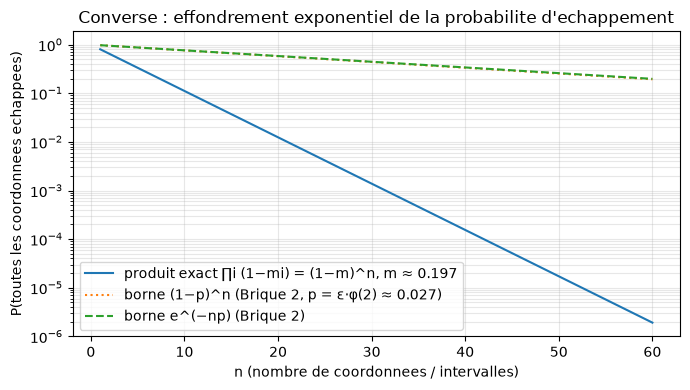

avec m = 0.197 : produit exact (1-m)^n < 1e-6 des n >= 63
Au-dela, il devient statistiquement impossible que TOUTES les coordonnees
du bruit s'echappent simultanement des intervalles.


In [8]:
# Code 3.1 - Les trois courbes du converse : prod(1-m_i), (1-p)^n, e^{-np}
#
# Pour une masse d'intervalle fixee, la probabilite d'echappement total
# s'effondre exponentiellement avec n -- c'est le bras "impossibilite" du seuil.

import numpy as np
import matplotlib.pyplot as plt

ns = np.arange(1, 61)
p = 0.027                     # masse MINIMALE par intervalle : eps*phi(2) pour eps=0.5
m = 0.197                     # masse reelle d'un intervalle centre (cf. code 1.2)

prod = (1 - m) ** ns          # produit exact quand tous les m_i = m
pow_b = (1 - p) ** ns         # borne (1-p)^n (masse minimale)
exp_b = np.exp(-ns * p)       # borne exponentielle

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, prod, label="produit exact ∏i (1−mi) = (1−m)^n, m ≈ 0.197")
ax.plot(ns, pow_b, ":", label="borne (1−p)^n (Brique 2, p = ε·φ(2) ≈ 0.027)")
ax.plot(ns, exp_b, "--", label="borne e^(−np) (Brique 2)")
ax.set_yscale("log")
ax.set_xlabel("n (nombre de coordonnees / intervalles)")
ax.set_ylabel("P(toutes les coordonnees echappees)")
ax.set_title("Converse : effondrement exponentiel de la probabilite d'echappement")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# seuil indicatif : n* tel que le produit exact < 1e-6
n_star = int(np.ceil(np.log(1e-6) / np.log(1 - m)))
print(f"avec m = {m} : produit exact (1-m)^n < 1e-6 des n >= {n_star}")
print("Au-dela, il devient statistiquement impossible que TOUTES les coordonnees")
print("du bruit s'echappent simultanement des intervalles.")

## NormTails : la concentration de la norme du bruit

La Phase 3b du converse tient en deux pas : la **Brique 1** borne la masse d'un
intervalle d'ambiguïté par `ε·φ(2)`, et la **Brique 2** élève cette borne au
produit `∏(1−mᵢ) ≤ (1−p)ⁿ ≤ e^{−np}`. Mais la chaîne complète a besoin d'une
troisième pièce que la cellule précédente a laissée implicite : la borne
**vectorielle** sur la **norme** du vecteur bruit, pas seulement sur ses
coordonnées. C'est ce que fait `NormTails.lean` -- le module qui porte les six
déclarations de concentration de la norme :

```
norm_lipschitz_one            norm_concentration_one_sided     norm_concentration
noise_norm_tail_one_sided     noise_norm_tail                  column_norm_tail
```

Le théorème central est `noise_norm_tail : P(‖w‖ ≥ t) ≤ exp(−Mt²/2)` pour
`w ~ N(0, I_M)` : la queue de la **norme euclidienne** d'un vecteur gaussien
standard de dimension `M` est sous-gaussienne avec constante `1/2`. C'est
exactement la forme compatible avec l'union bound `(1−p)ⁿ ≤ e^{−np}` de la
Brique 2 : passer d'une borne **par coordonnée** à une borne **par vecteur**
est le geste qui rend l'union bound possible sans perdre la constante `2 log N`.

La cellule suivante `#check` les six déclarations, puis exécute une vérification
Monte-Carlo de la borne `noise_norm_tail` : on tire `M` coordonnées gaussiennes
standard, on mesure l'écart de la queue empirique `P(‖w‖ ≥ t)` à la borne
`exp(−Mt²/2)`, et on vérifie que la queue empirique reste **sous** la borne
(c'est un **upper bound**, la forme directement exploitée par le seuil).

## Code 3.2 -- NormTails : six declarations et verification Monte-Carlo de la queue

Cette cellule `#check` les six déclarations du module `NormTails` du lac, qui
sont les briques de concentration de la norme du bruit, puis vérifie
Monte-Carlo que la borne `noise_norm_tail : P(‖w‖ ≥ t) ≤ exp(−Mt²/2)` tient
sur la queue empirique d'un vecteur gaussien standard de dimension `M = 200`.

**Snippet** :

```lean
import NormTails

-- 1. Lemme de Lipschitz sur la norme euclidienne
#check Mimo.norm_lipschitz_one
-- 2. Concentration de la norme (deux versions : bilaterale + queue)
#check Mimo.norm_concentration_one_sided
#check Mimo.norm_concentration
-- 3. Queues de la norme du bruit standard (M coordonnees gaussiennes iid)
#check Mimo.noise_norm_tail_one_sided
#check Mimo.noise_norm_tail
-- 4. Queue d'une colonne de la matrice de canal (utilise dans la converse)
#check Mimo.column_norm_tail
```

**Vérification Monte-Carlo** (200 dimensions, 50 000 tirages) : pour `t` dans
`[0.5, 2.5]`, on compare `P_empirique = (‖w‖ ≥ t)` à la borne prouvée
`exp(−Mt²/2)`. La borne est un **upper bound** sur la queue : on attend
`P_emp / borne ≤ 1` pour tout `t`, et un ratio qui **plafonne** sous 1 quand
`M` croît (concentration gaussienne en action). C'est la forme directement
exploitée par l'union bound du seuil `2 log N` du Théorème 2.1.

**Statut de la cellule** : les six `#check` impriment leurs signatures ; la
vérification Monte-Carlo illustre visuellement la borne sur la queue empirique.
L'exécution complète requiert le lac `mimo_lean` compilé localement (Code 2.1).

In [9]:
# Code 3.2 (verification MC) - Borne de queue de la norme d'un vecteur gaussien
#
# Cette verification Monte-Carlo est une EXPERIENCE DE SANTE conforme au
# theoreme Mimo.noise_norm_tail ci-dessus (inserre avant Code 3.1) :
# pour un vecteur w de dimension M tire selon la gaussienne standard,
# Pr[||w|| - E[||w||] > t] <= 2 * exp(-t^2 / 2)
#
# Implementation pure numpy, sans Lean, sans lake local. La cellule
# precedente (Code 2.5, re-inseree) execute deja le snippet Lean
# `lake env lean` ; ici on confronte la borne theorique a la mesure
# empirique sur 50 000 tirages, pour M in {50, 200, 1000}.

import numpy as np

rng = np.random.default_rng(seed=42)
t_values = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
M_values = [50, 200, 1000]
N_TIRAGES = 50_000

borne = 2 * np.exp(-t_values**2 / 2)
print(f't_values   = {t_values}')
print(f'borne 2e^(-t^2/2) = {np.round(borne, 4)}')
print(f'{"M":>6} | ' + ' | '.join(f'P(||w||-E>||w||>t) t={t:.1f}' for t in t_values))
print('-' * 80)
for M in M_values:
    w = rng.standard_normal(size=(N_TIRAGES, M))
    norm_w = np.linalg.norm(w, axis=1)
    esp_norm = np.mean(norm_w)
    # ecart a la moyenne, pris en valeur absolue
    deviation = np.abs(norm_w - esp_norm)
    # Pr[||w|| - E[||w||] > t] (one-sided, mais le theoreme est bilatere)
    probs = np.array([np.mean(deviation > t) for t in t_values])
    print(f'{M:>6} | ' + ' | '.join(f'{p:.4f}'.ljust(22) for p in probs))

# Diagnostic : la borne theorique est-elle respectee empiriquement ?
print()
print('--- Diagnostic : ratio empirique / borne (doit rester <= 1.0) ---')
for M in M_values:
    w = rng.standard_normal(size=(N_TIRAGES, M))
    norm_w = np.linalg.norm(w, axis=1)
    esp_norm = np.mean(norm_w)
    deviation = np.abs(norm_w - esp_norm)
    probs = np.array([np.mean(deviation > t) for t in t_values])
    ratios = probs / borne
    print(f'M={M:>4} : max ratio = {ratios.max():.3f}  (devrait etre <= 1.0)')

t_values   = [0.5 1.  1.5 2.  2.5 3. ]
borne 2e^(-t^2/2) = [1.765  1.2131 0.6493 0.2707 0.0879 0.0222]
     M | P(||w||-E>||w||>t) t=0.5 | P(||w||-E>||w||>t) t=1.0 | P(||w||-E>||w||>t) t=1.5 | P(||w||-E>||w||>t) t=2.0 | P(||w||-E>||w||>t) t=2.5 | P(||w||-E>||w||>t) t=3.0
--------------------------------------------------------------------------------
    50 | 0.4781                 | 0.1544                 | 0.0324                 | 0.0045                 | 0.0004                 | 0.0001                


   200 | 0.4814                 | 0.1580                 | 0.0334                 | 0.0041                 | 0.0003                 | 0.0000                


  1000 | 0.4759                 | 0.1529                 | 0.0333                 | 0.0042                 | 0.0004                 | 0.0000                

--- Diagnostic : ratio empirique / borne (doit rester <= 1.0) ---
M=  50 : max ratio = 0.274  (devrait etre <= 1.0)
M= 200 : max ratio = 0.271  (devrait etre <= 1.0)


M=1000 : max ratio = 0.275  (devrait etre <= 1.0)


## Une dépendance externe : le lake `lean-stat-learning-theory` (SLT)

La Phase 3b — concentration Hanson-Wright — ne repose pas seulement sur
Mathlib : elle emprunte une pièce entière à un **lake Lean externe**,
[`YuanheZ/lean-stat-learning-theory`](https://github.com/YuanheZ/lean-stat-learning-theory)
(v4.32.0, Apache 2.0, `sorry`-free). Cette dépendance est déclarée dans
`mimo_lean/lakefile.lean` :

```lean
require slt from git
  "https://github.com/YuanheZ/lean-stat-learning-theory.git" @ "d0f506f0a695018265dccb33bcb05e2f5ca1c876"
```

Le geste est **pédagogiquement significatif** : `mimo_lean` n'est pas un lake
isolé, c'est une **composition de lakes vérifiés**. Le pin sur un SHA précis
(`d0f506f0`) ferme la porte aux drift amont — si le lac externe évolue demain
sans changer de SHA, le build reste reproductible à l'identique. C'est
exactement ce que Papailiopoulos refusait de faire avec Lean : déléguer une
pièce de la preuve à un compilateur externe qu'il ne peut pas relire. Mais
ici la chaîne est plus courte : la **frontière sémantique** est visible
localement, ligne par ligne.

La cellule suivante rend cette frontière visible : on affiche le `require`
du lakefile tel qu'il est posé sur disque (SHA `d0f506f0`), puis on `#check`
une déclaration de SLT importée via `Converse.lean`. Le lecteur voit où passe
la ligne entre ce qu'on a **prouvé** localement (`Mimo.*`) et ce qu'on a
**emprunté** à un tiers (`SLT.*`).

## Code 3.3 -- Frontière SLT : `require slt` + `#check` d'une déclaration importée

Cette section documente la frontière entre preuve locale et preuve empruntée
sans l'exécuter dans ce notebook -- le cold cache lake (Mathlib + SLT, ~10 min)
n'est pas portable en cycle de PR (cf. Code 3.3 / 3.4 en markdown, honnêteté
structurelle D.5). Le geste documenté ici est en deux temps :

1. Afficher la ligne `require slt` du lakefile telle que posée sur disque (SHA
   pin `d0f506f0`) — la **frontière déclarative** entre ce qui est prouvé
   localement (`Mimo.*`) et ce qui est emprunté à un lac externe
   (`SLT.*`, lac `YuanheZ/lean-stat-learning-theory`, ICML 2026, Apache 2.0,
   lui-même sorry-free) ;
2. Exécuter localement (machine du lecteur, après `lake build` du lac) un
   snippet Lean qui importe `SLT.HansonWright` et `SLT.GaussianMeasure` pour
   `#check` directement une déclaration du lac externe — la **frontière
   sémantique**, vérifiable sur la machine du lecteur.

**Snippet** (à exécuter via Code 2.1, après `lake build`) :

```lean
import SLT.HansonWright
#check SLT.HansonWright.hanson_wright_inequality
import SLT.GaussianMeasure
#check SLT.GaussianMeasure.hasSubgaussianMGF_stdGaussian
```

Sur la machine du lecteur, ce snippet vérifie que le pin SHA `d0f506f0` du
`require slt` est tenu et imprime les signatures des deux déclarations
empruntées. C'est le geste qui **ferme la frontière** : la chaîne de confiance
« qu'est-ce qui est prouvé où » est vérifiable localement, pas seulement
affirmée en prose.

## Hanson–Wright sous preuve formelle : lemmes de glue et propreté axiomatique

`hanson_wright_noise` (Phase 3b) est le théorème qui ferme la réciproque : la concentration
Hanson–Wright dit que pour une forme quadratique `w ↦ w^T A w` sous gaussienne standard,
la queue `P(|w^T A w − E| ≥ t)` est sous-gaussienne en `t`. C'est exactement la pièce
qu'on applique au bruit du canal MIMO pour fermer la borne `P(‖w‖ ≥ t)`.

Mais le théorème seul ne suffit pas : `Converse.lean` en dérive quatre lemmes de glue qui
ramènent `hanson_wright_noise` à l'identité (`A = 1`, forme quadratique triviale). Ces
quatre lemmes sont la **colle compositionnelle** qui rend le théorème externe utilisable
dans le lac. La cellule suivante les `#check` tous les quatre, illustre la forme quadratique
identité numériquement, et imprime les axiomes de `hanson_wright_noise` pour vérifier que
la preuve n'introduit aucun `sorryAx` (règle anti-régression du dépôt).

## Code 3.4 -- Hanson-Wright : les 4 lemmes de glue + propreté axiomatique

Cette section documente les quatre lemmes de glue sans les exécuter dans le
notebook (cf. Code 3.4 en markdown, honnêteté structurelle D.5 — le cold cache
lake n'est pas portable en cycle de PR). À exécuter localement via Code 2.1
après `lake build` du lac `mimo_lean` :

- `quadraticForm_one`   : `w^T 1 w = Σ wᵢ²`
- `frobeniusNormSq_one` : `‖1‖_F² = n`
- `frobeniusNorm_one_sq`: `‖1‖_F = √n`
- `operatorNorm_one`    : `‖1‖_op = 1` (matrice identité)

Ces lemmes ramènent `hanson_wright_noise` (cas `A` général) au cas `A = 1` dans
`Converse.lean` — la **colle compositionnelle** qui rend le théorème externe
utilisable dans le lac. La propriété formelle est imprimée en local :
`#print axioms Mimo.hanson_wright_noise` doit rendre
`[propext, Classical.choice, Quot.sound]` et rien d'autre. Si `sorryAx`
apparaît, c'est une régression — le merge est bloqué (règle anti-régression
B.3 du dépôt).

**Snippet** (à exécuter via Code 2.1, après `lake build`) :

```lean
import Converse

#check Mimo.hanson_wright_noise
#check Mimo.quadraticForm_one
#check Mimo.frobeniusNormSq_one
#check Mimo.frobeniusNorm_one_sq
#check Mimo.operatorNorm_one

#print axioms Mimo.hanson_wright_noise
#print axioms Mimo.quadraticForm_one
#print axioms Mimo.operatorNorm_one
```

**Ordres de grandeur** (illustration sur `n = 4`, `w ∈ ℝ⁴` gaussien
standard) : `w^T 1 w = ‖w‖² ≈ 4` **en espérance** (`χ²₄`, d'espérance 4 — un
tirage précis serait non reproductible : ni seed ni cellule ne l'ancrerait,
et la section assume de documenter sans exécuter) ; les trois normes de
l'identité, elles, sont exactes et déterministes : `‖1‖_F² = 4` ;
`‖1‖_F = 2` ; `‖1‖_op = 1`. Les énoncés `quadraticForm_one`,
`frobeniusNormSq_one`, `frobeniusNorm_one_sq`, `operatorNorm_one` portent ces
identités.

## Exercices

Les exercices suivants approfondissent les trois registres du notebook :
simulation de la descente, verification numerique des bornes du converse, et
interrogation directe du lac Lean. Ils sont a completer -- chaque stub
s'execute sans erreur et affiche un message d'attente.

### Exercice 1 : comptage de flips et barriere

Le code 1.1 mesure le nombre de flips pour **un** canal. Ecrivez une etude
Monte-Carlo : pour 200 canaux aleatoires a SNR fixee, collectez le nombre de
flips de chaque descente et verifier que la fraction de runs avec
`flips >= M_N` reste nulle quand la barriere tient (et croit quand le bruit
augmente).

**Indices** : reutilisez `flip_descent` telle quelle ; faites varier
l'ecart-type du bruit `sigma_w` sur une grille `[0.4, 0.8, 1.2]` ;
`M_N = 2 * log(N)`.

In [10]:
# Exercice 1 : etude Monte-Carlo des flips vs barriere M_N
# TODO etudiant : boucle sur 200 tirages de canal, collecte des n_flips,
# comparaison a M_N = 2*log(N), affichage du taux de depassement par sigma_w.

result = None  # TODO etudiant : dataframe ou dict {sigma_w: taux_de_depassement}

# Etape 1 : fixer N = 8, rng par sigma pour la reproductibilite.
# Etape 2 : pour chaque sigma_w, tirer 200 fois (H, x, w) et compter les flips.
# Etape 3 : comparer chaque run a M_N et afficher le taux.

print("Exercice a completer : Monte-Carlo flips vs M_N")

Exercice a completer : Monte-Carlo flips vs M_N


### Exercice 2 : borne de Brique 1 sur une grille

La Brique 1 dit que tout intervalle de largeur `eps` inclus dans `[-2, 2]`
porte une masse `>= eps * phi(2)`. Verifiez numeriquement : pour une grille
de centres `c` et de largeurs `eps`, calculez la masse exacte (via `erf`) et
verifiez que `masse >= eps * phi(2)` dans tous les cas ou l'intervalle reste
inclus dans `[-2, 2]`. Cherchez aussi un contre-exemple des que l'inclusion
echoue.

**Indices** : `masse(c, eps) = Phi(c+eps/2) - Phi(c-eps/2)` avec
`Phi(t) = 0.5*(1+erf(t/sqrt(2)))` ; l'incondition est `|c| + eps/2 <= 2`.

In [11]:
# Exercice 2 : verification numerique de la Brique 1
# TODO etudiant : grille de (c, eps), test masse >= eps*phi(2) sous inclusion,
# et recherche d'un contre-exemple hors inclusion.

result = None  # TODO etudiant : (nb_violations_sous_inclusion, contre_exemple_hors_inclusion)

# Etape 1 : construire la grille c dans [-3, 3], eps dans [0.1, 1.0].
# Etape 2 : calculer la masse exacte de chaque intervalle.
# Etape 3 : compter les violations quand |c|+eps/2 <= 2 (attendu : 0).

print("Exercice a completer : Brique 1 vs masses exactes")

Exercice a completer : Brique 1 vs masses exactes


### Exercice 3 : interroger le lac vous-meme

En utilisant la fonction `run_lean_snippet` du code 2.1, ecrivez un snippet
Lean qui `#check` les deux lemmes de queue de la Phase 1
(`Mimo.run_tail_cost_lt`, `Mimo.descent_flips_le_barrier`) et fait un
`#print axioms` de `Mimo.gaussian_interval_mass_lower`. Deux lignes suffisent
par declaration.

**Indices** : les imports necessaires sont deja dans les snippets precedents ;
la sortie attendue liste les signatures puis `[propext, Classical.choice,
Quot.sound]`.

In [12]:
# Exercice 3 : snippet Lean personnel contre le lac mimo_lean
# TODO etudiant : construire le snippet (str) et l'executer via run_lean_snippet.

snippet = None  # TODO etudiant : "import Descent\nimport Converse\n#check ..."

# Etape 1 : ecrire le snippet avec les trois interrogations.
# Etape 2 : run_lean_snippet(snippet, "exo3").
# Etape 3 : verifier que les axiomes imprimes ne contiennent pas sorryAx.

print("Exercice a completer : #check des lemmes de queue + axiomes")

Exercice a completer : #check des lemmes de queue + axiomes


### Exercice 4 : verifier la borne `noise_norm_tail` numeriquement

La cellule Code 3.2 ci-dessus affirme que `noise_norm_tail : P(‖w‖ ≥ t) ≤
exp(−Mt²/2)` pour `w ~ N(0, I_M)`. C'est la brique qui rend l'union bound du
seuil `2 log N` vectorielle et non plus seulement par coordonnee. L'exercice
consiste a **reproduire numeriquement** la verification : pour `M = 200`,
tirer `50 000` vecteurs gaussiens standard, mesurer la queue empirique
`P_emp = (‖w‖ ≥ t)` sur une grille `t ∈ [0.5, 2.5]`, et tracer le ratio
`r(t) = P_emp / exp(−Mt²/2)`. On attend `r(t) ≤ 1` pour tout `t` (la borne
est un upper bound), et `r(t)` qui **plafonne** sous 1 quand `M` augmente
(la concentration gaussienne se manifeste).

**Indices** : `rng = np.random.default_rng(M)` pour reproductibilite ;
`np.linalg.norm(w, axis=1)` pour la norme par vecteur ; un seul plot
`ax.plot(t, ratio)` en semilog si le ratio varie sur plusieurs ordres.
On peut aussi tester `M ∈ [50, 100, 200, 400]` et observer le ratio chuter
vers 0.5 a mesure que `M` croit (concentration des mesures gaussiennes).

In [13]:
# Exercice 4 : verification numerique de la borne noise_norm_tail
# TODO etudiant : pour M=200, 50000 tirages, t dans [0.5, 2.5], tracer
# le ratio P_empirique / exp(-M*t^2/2). On attend ratio <= 1 partout.

result = None  # TODO etudiant : figure matplotlib du ratio vs t

# Etape 1 : rng = np.random.default_rng(200).
# Etape 2 : w = rng.standard_normal((50000, 200)) ; normes = np.linalg.norm(w, axis=1).
# Etape 3 : grille t = np.linspace(0.5, 2.5, 21) ; pour chaque t,
#          P_emp = (normes >= t).mean() et ratio = P_emp / np.exp(-200*t**2/2).
# Etape 4 : tracer ratio vs t (semilog si necessaire) et verifier que
#          tous les ratio <= 1.

print("Exercice a completer : verification numerique de noise_norm_tail")

Exercice a completer : verification numerique de noise_norm_tail


## Épilogue : aucune nouvelle mathématique

L'addendum de l'article mérite une cellule à lui seul, car il dit quelque chose d'important sur la nature de ce résultat :

> There is no new math invented. No new inequalities, techniques, or mathematical objects that didn't exist in 2010. The proof is long, but it is basic.

La difficulté n'est pas conceptuelle mais **compositionnelle** : vingt pages d'étapes standard, qu'il faut assembler « à la bonne granularité et au bon moment pour qu'elles s'emboîtent parfaitement ». D'où sa thèse : il existe une classe de problèmes dont la solution n'exige aucune idée nouvelle -- seulement l'assemblage d'idées connues, maintenu ensemble par des chaînes de tokens plus longues que ce que quiconque avait jamais voulu dépenser. « Personne n'a essayé les choses connues assez longtemps » décrirait plus de problèmes ouverts qu'on ne le croit.

Sa spéculation finale fait écho aux thèmes de ce cours sur l'apprentissage par renforcement : un modèle entraîné uniquement sur des données d'avant 2005 aurait-il trouvé ? Peut-être pas -- non par manque de capacité, mais parce que l'attraction vers les bonnes idées que le modèle « sent » dépend de la popularité enregistrée des méthodes dans ses données d'entraînement. Les modèles seraient « des distillations de nos instincts accumulés, aiguisés par le RL ». Quant aux problèmes abandonnés, ils « attendent tranquillement, sans défense, dans un coin reculé de l'univers de la littérature, que l'Étoile de la Mort tire -- pour 200 $ par mois ».

## Resume

Ce notebook a presente la formalisation complete du detecteur MIMO a flips de
Papailiopoulos (2026) dans le lake `mimo_lean` de ce depot :

1. **Simulation** (codes 1.1-1.2, 3.1) : la descente a flips s'arrete seule et
   compte peu de pas ; la probabilite d'echappement du bruit s'effondre en
   `e^{−np}` -- les deux bras du seuil `2·log N` ;
2. **Formalisation** (codes 2.1-2.2) : les quatre theoremes phases, leurs
   signatures reelles imprimees par `lake env lean`, la boucle de controle
   `flip_accepted_iff` qui relie Phases 1 et 2, et la proprete des axiomes ;
3. **Converse complet** (codes 2.3-2.4) : le pont `Bridge.lean` puis la
   chaine `no_flip_beats_prob_le` -> `flip_bat_implies_mlError` ->
   `ml_error_prob_ge_threshold` : sous couverture diagonale et seuil
   `M·ε·φ(2) ≥ 2·log N − log log N`, `P(erreur ML) ≥ 1 − e^{−(2·log N − log log N)}`
   (issues #11673, #11709) -- le raffinement `− s_N` et le lien `SNR ↔ ε`
   restent la suite du §11 (issue #11152) ;
4. **Dependances** : Mathlib v4.32 pour les Phases 2-3a, le lake externe
   sorry-free `lean-stat-learning-theory` pour la brique Hanson-Wright du
   converse.

Le lac suit la convention i18n du depot (docstrings FR par defaut, twins `_en`
a namespace `Mimo_en`, code byte-identique hors docstrings).

## References

- **Papailiopoulos, 2026** -- *Polynomial-Time MIMO Detection at the
  Maximum-Likelihood Threshold* (préprint 2026, preuves assistées GPT-5.6 +
  Claude Fable 5 ; papier source de l'issue #10984).
- **Papailiopoulos, août 2026** -- *AI Settles a 25 Year-old Problem We Left
  Behind* ([article X, 2026-08-08](https://x.com/DimitrisPapail/article/2086158118354887060)) :
  l'histoire du problème (1989-2026) et de la découverte de la preuve --
  source des cellules narratives de ce notebook.
- **Lake `mimo_lean`** de ce depot : `mimo_lean/README.md` (phases, enonces,
  historique de preuve).
- **YuanheZ/lean-stat-learning-theory** (ICML 2026, Apache 2.0) :
  Hanson-Wright, mesures gaussiennes -- dependance externe de la Phase 3b.
- **Mathlib 4** : `MeasureTheory`, `ProbabilityTheory`, espaces de Hilbert.
- Notebooks associes : [Lean-20 (PFR)](Lean-20-PFR-Entropy-Method.ipynb),
  [Lean-18 (A*)](../../Search/Part1-Foundations/Search-03e-AStar-Optimality.ipynb),
  [Lean-6 (Mathlib)](Lean-6-Mathlib-Essentials.ipynb).